In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_moons
from sklearn.model_selection import train_test_split

In [2]:
X, y = make_classification(n_features=2, n_redundant=0, n_informative=2,
                           random_state=1, n_clusters_per_class=1)

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (100, 2)
Shape of y: (100,)


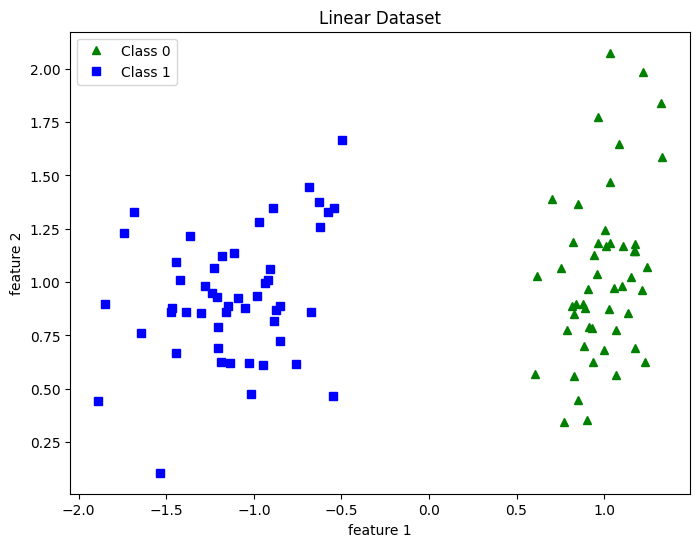

In [3]:
fig = plt.figure(figsize=(8, 6))
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "g^", label="Class 0")
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs", label="Class 1")
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.legend()
plt.title("Linear Dataset")
plt.show()

In [4]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0, shuffle=True)

print(f"Training shape: {x_train.shape}")
print(f"Testing shape: {x_test.shape}")

Training shape: (80, 2)
Testing shape: (20, 2)


In [5]:
class LogisticRegressionFromScratch:
    def __init__(self, learning_rate=0.01, num_iterations=1000):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.w = None
        self.b = None
        self.costs = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        m, n = X.shape

        y = y.reshape(-1, 1)

        self.w = np.zeros((n, 1))
        self.b = 0

        for i in range(self.num_iterations):
            Z = np.dot(X, self.w) + self.b
            A = self.sigmoid(Z)

            cost = -(1/m) * np.sum(y * np.log(A) + (1-y) * np.log(1-A))

            dw = (1/m) * np.dot(X.T, (A - y))
            db = (1/m) * np.sum(A - y)

            self.w = self.w - self.learning_rate * dw
            self.b = self.b - self.learning_rate * db

            if i % 100 == 0:
                self.costs.append(cost)

    def predict(self, X):
        m = X.shape[0]
        y_pred = np.zeros((m, 1))

        Z = np.dot(X, self.w) + self.b
        A = self.sigmoid(Z)

        y_pred = [1 if i > 0.5 else 0 for i in A]

        return np.array(y_pred)

In [6]:
classifier = LogisticRegressionFromScratch(learning_rate=0.1, num_iterations=2000)
classifier.fit(x_train, y_train)

print("Training complete.")
print(f"Learned Weights (w): \n{classifier.w}")
print(f"Learned Bias (b): {classifier.b}")

Training complete.
Learned Weights (w): 
[[-5.48966292]
 [ 0.21234227]]
Learned Bias (b): 0.0524324257504914


In [7]:
y_pred = classifier.predict(x_test)

accuracy = np.mean(y_pred == y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 100.00%


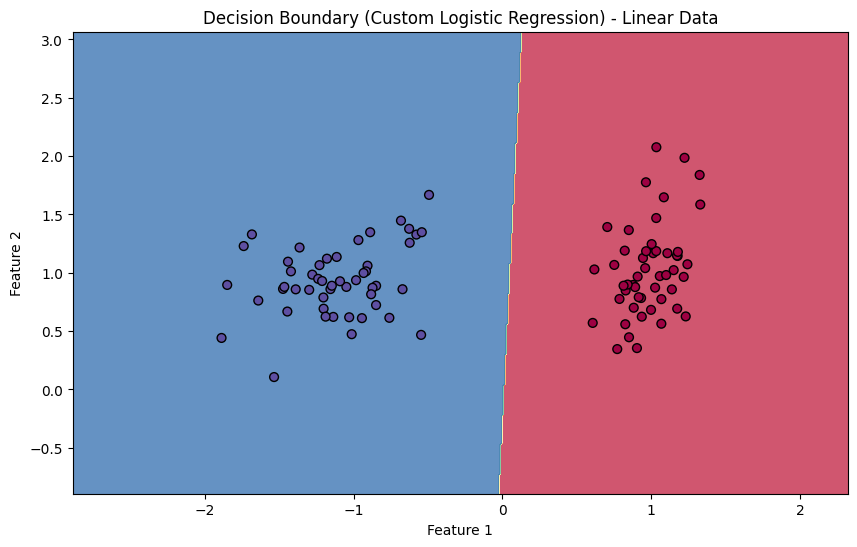

In [8]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = classifier.predict(grid_points)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Spectral)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, edgecolors='k', cmap=plt.cm.Spectral)
plt.title("Decision Boundary (Custom Logistic Regression) - Linear Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

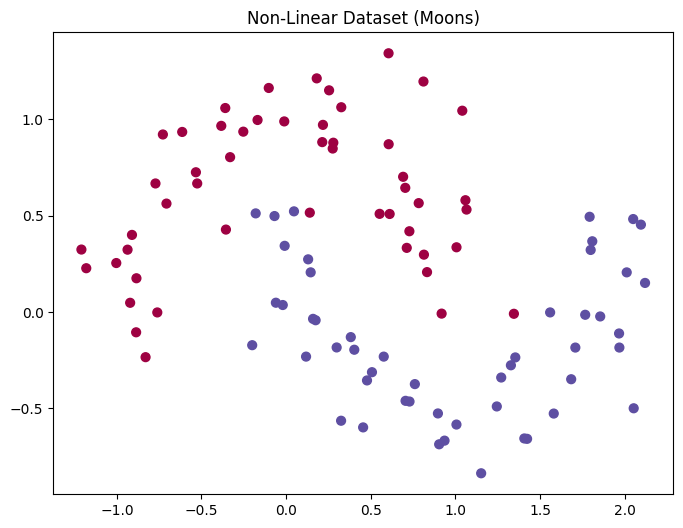

In [15]:
X_moon, y_moon = make_moons(n_samples=100, noise=0.2, random_state=0)

plt.figure(figsize=(8, 6))
plt.scatter(X_moon[:, 0], X_moon[:, 1], c=y_moon, s=40, cmap=plt.cm.Spectral)
plt.title("Non-Linear Dataset (Moons)")
plt.show()

In [10]:
x_train_moon, x_test_moon, y_train_moon, y_test_moon = train_test_split(
    X_moon, y_moon, test_size=0.20, random_state=0, shuffle=True
)

In [18]:
classifier_moon = LogisticRegressionFromScratch(learning_rate=0.1, num_iterations=3000)
classifier_moon.fit(x_train_moon, y_train_moon)
print("Training complete on Moons dataset.")

y_train_pred_moon = classifier_moon.predict(x_train_moon)
train_accuracy_moon = np.mean(y_train_pred_moon.flatten() == y_train_moon)
print(f"Train Accuracy (Moons): {train_accuracy_moon * 100:.2f}%")

Training complete on Moons dataset.
Train Accuracy (Moons): 88.75%


In [12]:
y_pred_moon = classifier_moon.predict(x_test_moon)

accuracy_moon = np.mean(y_pred_moon == y_test_moon)
print(f"Test Accuracy (Moons): {accuracy_moon * 100:.2f}%")

Test Accuracy (Moons): 85.00%


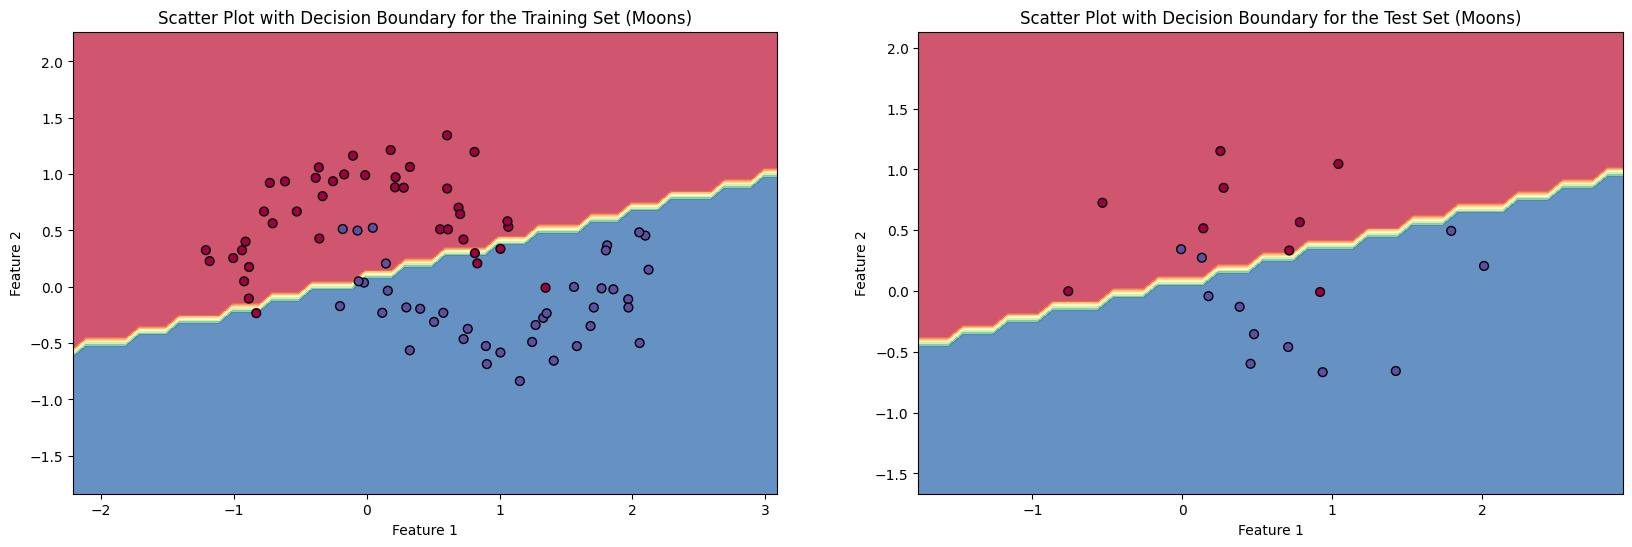

In [16]:
x_min, x_max = x_train_moon[:, 0].min() - 1, x_train_moon[:, 0].max() + 1
y_min, y_max = x_train_moon[:, 1].min() - 1, x_train_moon[:, 1].max() + 1

xx_train, yy_train = np.meshgrid(np.arange(x_min, x_max, 0.1),
                                 np.arange(y_min, y_max, 0.1))

Z_train = classifier_moon.predict(np.c_[xx_train.ravel(), yy_train.ravel()])
Z_train = Z_train.reshape(xx_train.shape)


x_min_test, x_max_test = x_test_moon[:, 0].min() - 1, x_test_moon[:, 0].max() + 1
y_min_test, y_max_test = x_test_moon[:, 1].min() - 1, x_test_moon[:, 1].max() + 1

xx_test, yy_test = np.meshgrid(np.arange(x_min_test, x_max_test, 0.1),
                               np.arange(y_min_test, y_max_test, 0.1))

Z_test = classifier_moon.predict(np.c_[xx_test.ravel(), yy_test.ravel()])
Z_test = Z_test.reshape(xx_test.shape)


plt.figure(figsize = (20, 6))


plt.subplot(1, 2, 1)
plt.contourf(xx_train, yy_train, Z_train, alpha=0.8, cmap=plt.cm.Spectral)
plt.scatter(x_train_moon[:, 0], x_train_moon[:, 1], c=y_train_moon, s=40, edgecolors='k', cmap=plt.cm.Spectral)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Scatter Plot with Decision Boundary for the Training Set (Moons)')

plt.subplot(1, 2, 2)
plt.contourf(xx_test, yy_test, Z_test, alpha=0.8, cmap=plt.cm.Spectral)
plt.scatter(x_test_moon[:, 0], x_test_moon[:, 1], c=y_test_moon, s=40, edgecolors='k', cmap=plt.cm.Spectral)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Scatter Plot with Decision Boundary for the Test Set (Moons)')

plt.show()